# Resume-to-Job Matching Assistant

This notebook ranks job postings against a resume using two signals:
1. Text similarity using TF-IDF + cosine similarity
2. Skill overlap score

The final ranking combines both into a weighted prototype score.

## Prototype Scope

This notebook implements the baseline version of the Resume-to-Job Matching Assistant 
using TF-IDF and skill overlap. It does not yet include semantic similarity or advanced 
context understanding, which will be introduced in the next stage.

## 1) Imports and Setup
Load required libraries for data handling, NLP preprocessing, matching, and visualization.

In [1]:
import re
import string

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 2) Load Input Data
Read the resume text and job postings dataset, then preview both.

In [3]:
with open("../data/resume.txt", "r", encoding="utf-8") as file:
    resume_text = file.read()

jobs_df = pd.read_csv("../data/jobs.csv")

print("Resume loaded successfully.")
print("Resume preview:")
print(resume_text[:300])
print("\nJobs loaded successfully.")
jobs_df.head()

Resume loaded successfully.
Resume preview:
Basil Behanan
Tel: +61 468410310
Email: Basilbehanan5@gmail.com
LinkedIn: LinkedIn

Career Profile
Final-year Computer Science student majoring in Data Science with experience applying data analytics, machine learning, and data engineering techniques to solve complex problems. Skilled in extracting,

Jobs loaded successfully.


,job_id,title,company,description
0,1,Data Analyst,Company A,Looking for a candidate with experience in Pyt...
1,2,Junior Data Scientist,Company B,Seeking a graduate with experience in machine ...
2,3,Machine Learning Intern,Company C,The ideal applicant has worked on machine lear...
3,4,AI Engineer Intern,Company D,Looking for students with exposure to deep lea...
4,5,Business Intelligence Analyst,Company E,"Candidates should have knowledge of SQL, repor..."


## 3) Text Preprocessing
Normalize text by lowercasing, removing punctuation, tokenizing, and dropping stopwords.

In [4]:
nltk.download("punkt")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    cleaned_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(cleaned_tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bazil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bazil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
cleaned_resume_text = preprocess_text(resume_text)
jobs_df["cleaned_description"] = jobs_df["description"].apply(preprocess_text)
cleaned_job_texts = jobs_df["cleaned_description"].tolist()

print("Preprocessing complete.")
print(f"Number of jobs processed: {len(cleaned_job_texts)}")
jobs_df[["title", "company", "cleaned_description"]].head()

Preprocessing complete.
Number of jobs processed: 5


,title,company,cleaned_description
0,Data Analyst,Company A,looking candidate experience python sql dashbo...
1,Junior Data Scientist,Company B,seeking graduate experience machine learning p...
2,Machine Learning Intern,Company C,ideal applicant worked machine learning projec...
3,AI Engineer Intern,Company D,looking students exposure deep learning nlp py...
4,Business Intelligence Analyst,Company E,candidates knowledge sql reporting dashboard c...


## 4) Text Similarity Matching
Use TF-IDF vectors and cosine similarity to score each job against the resume.

In [6]:
all_documents = [cleaned_resume_text] + cleaned_job_texts
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_documents)

resume_vector = tfidf_matrix[0:1]
job_vectors = tfidf_matrix[1:]
similarity_scores = cosine_similarity(resume_vector, job_vectors)[0]

jobs_df["similarity_score"] = similarity_scores
jobs_df["match_percentage"] = (jobs_df["similarity_score"] * 100).round(2)

jobs_df[["title", "company", "match_percentage"]].sort_values(
    by="match_percentage", ascending=False
).head()

,title,company,match_percentage
1,Junior Data Scientist,Company B,30.77
2,Machine Learning Intern,Company C,22.43
3,AI Engineer Intern,Company D,18.68
0,Data Analyst,Company A,12.12
4,Business Intelligence Analyst,Company E,4.05


## 5) Skill Extraction and Overlap
Extract known skills from both resume and jobs, then compute matched and missing skills.

Note: Skill extraction is based on direct string matching and may fail for synonyms or variations in wording

In [13]:
skill_list = [
    "python", "sql", "excel", "tableau", "power bi", "machine learning",
    "deep learning", "data analysis", "data visualization", "nlp",
    "computer vision", "opencv", "yolo", "pandas", "numpy",
    "scikit-learn", "tensorflow", "pytorch", "git", "aws",
    "feature engineering", "model evaluation", "dashboard", "reporting",
    "statistics", "data preprocessing", "business intelligence"
]

def extract_skills(text, skills):
    text = text.lower()
    return sorted({skill for skill in skills if skill in text})

def compare_skills(resume_skills, job_skills):
    matched = sorted(set(resume_skills).intersection(set(job_skills)))
    missing = sorted(set(job_skills) - set(resume_skills))
    return matched, missing

def skill_overlap_score(job_skills, matched_skills):
    return 0 if not job_skills else len(matched_skills) / len(job_skills)

In [8]:
resume_skills = extract_skills(cleaned_resume_text, skill_list)
jobs_df["job_skills"] = jobs_df["cleaned_description"].apply(lambda x: extract_skills(x, skill_list))

jobs_df[["matched_skills", "missing_skills"]] = jobs_df.apply(
    lambda row: pd.Series(compare_skills(resume_skills, row["job_skills"])), axis=1
)

jobs_df["skill_overlap_score"] = (
    jobs_df.apply(lambda row: skill_overlap_score(row["job_skills"], row["matched_skills"]), axis=1) * 100
).round(2)

jobs_df[["title", "matched_skills", "missing_skills", "skill_overlap_score"]].head()

,title,matched_skills,missing_skills,skill_overlap_score
0,Data Analyst,"[power bi, python, sql]","[dashboard, data visualization, reporting, tab...",42.86
1,Junior Data Scientist,"[feature engineering, machine learning, model ...",[data preprocessing],80.00
2,Machine Learning Intern,"[computer vision, machine learning, python]",[],100.00
3,AI Engineer Intern,[python],"[deep learning, nlp]",33.33
4,Business Intelligence Analyst,"[excel, power bi, sql]","[dashboard, reporting]",60.00


## 6) Final Scoring and Ranking
Create a combined prototype score and build the final ranked results table.

In [9]:
jobs_df["prototype_score"] = (
    0.7 * jobs_df["match_percentage"] + 0.3 * jobs_df["skill_overlap_score"]
).round(2)

ranked_jobs = jobs_df.sort_values(by="prototype_score", ascending=False).reset_index(drop=True)

final_results = ranked_jobs[[
    "title",
    "company",
    "match_percentage",
    "skill_overlap_score",
    "prototype_score",
    "matched_skills",
    "missing_skills",
]].copy()

final_results["matched_skills"] = final_results["matched_skills"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) and x else "None"
)
final_results["missing_skills"] = final_results["missing_skills"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) and x else "None"
)

final_results

,title,company,match_percentage,skill_overlap_score,prototype_score,matched_skills,missing_skills
0,Machine Learning Intern,Company C,22.43,100.00,45.70,"computer vision, machine learning, python",None
1,Junior Data Scientist,Company B,30.77,80.00,45.54,"feature engineering, machine learning, model e...",data preprocessing
2,AI Engineer Intern,Company D,18.68,33.33,23.07,python,"deep learning, nlp"
3,Data Analyst,Company A,12.12,42.86,21.34,"power bi, python, sql","dashboard, data visualization, reporting, tableau"
4,Business Intelligence Analyst,Company E,4.05,60.00,20.84,"excel, power bi, sql","dashboard, reporting"


## Scoring Strategy Justification

The prototype score combines text similarity (70%) and skill overlap (30%). 
Text similarity is given higher weight because TF-IDF captures overall alignment 
between the resume and job description, while skill overlap provides interpretability 
by highlighting specific matching and missing skills.

The weights are heuristic and not learned from data. They are chosen to balance 
global text similarity with explicit skill matching. In future work, these weights 
could be tuned or learned from real hiring data.

## 7) Reporting, Visualization, and Export
Present ranked output, plot scores, and save artifacts to the outputs folder.

In [10]:
print("Resume-to-Job Matching Assistant - Prototype Results\n")
for i, row in final_results.iterrows():
    print(f"Rank {i + 1}: {row['title']} at {row['company']}")
    print(f"Text Match Score: {row['match_percentage']}%")
    print(f"Skill Overlap Score: {row['skill_overlap_score']}%")
    print(f"Prototype Score: {row['prototype_score']}%")
    print(f"Matched Skills: {row['matched_skills']}")
    print(f"Missing Skills: {row['missing_skills']}")
    print("-" * 80)

Resume-to-Job Matching Assistant - Prototype Results

Rank 1: Machine Learning Intern at Company C
Text Match Score: 22.43%
Skill Overlap Score: 100.0%
Prototype Score: 45.7%
Matched Skills: computer vision, machine learning, python
Missing Skills: None
--------------------------------------------------------------------------------
Rank 2: Junior Data Scientist at Company B
Text Match Score: 30.77%
Skill Overlap Score: 80.0%
Prototype Score: 45.54%
Matched Skills: feature engineering, machine learning, model evaluation, python
Missing Skills: data preprocessing
--------------------------------------------------------------------------------
Rank 3: AI Engineer Intern at Company D
Text Match Score: 18.68%
Skill Overlap Score: 33.33%
Prototype Score: 23.07%
Matched Skills: python
Missing Skills: deep learning, nlp
--------------------------------------------------------------------------------
Rank 4: Data Analyst at Company A
Text Match Score: 12.12%
Skill Overlap Score: 42.86%
Prototy

## Result Evaluation

The ranking produced by the prototype shows that roles aligned with data science 
and machine learning receive higher scores, which is consistent with the candidate’s 
background. Roles requiring business intelligence or reporting tools rank lower 
when fewer matching skills are present.

However, some limitations are observed:
- Jobs with similar meaning but different wording may receive lower scores
- Skill matching depends on exact phrase matching
- Some relevant skills may not be captured in the predefined skill list

These observations highlight the limitations of keyword-based approaches and 
motivate the need for semantic similarity in the next stage.

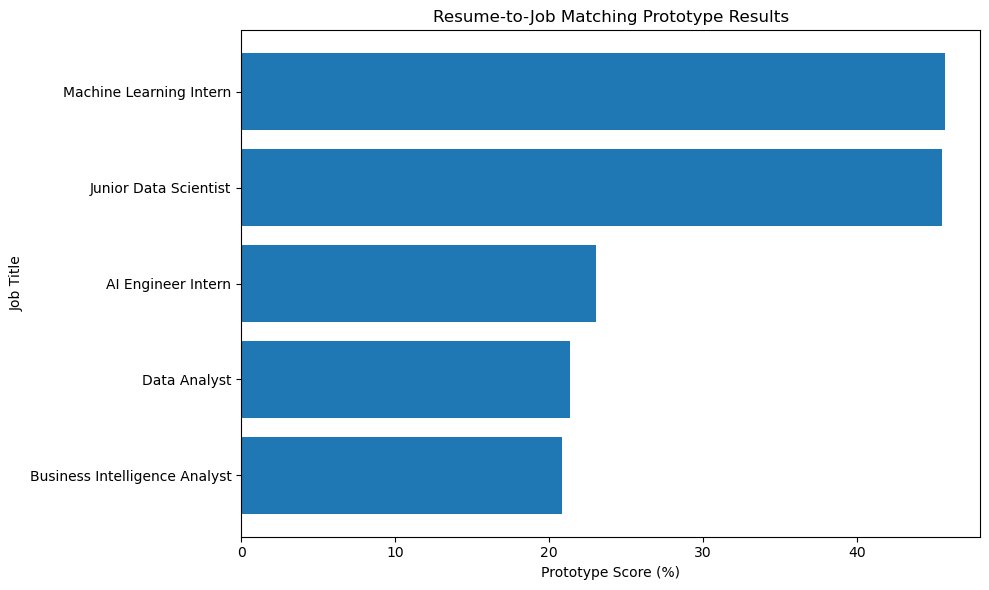

Chart saved to ../outputs/prototype_results_chart.png


In [11]:
plt.figure(figsize=(10, 6))
plt.barh(final_results["title"], final_results["prototype_score"])
plt.xlabel("Prototype Score (%)")
plt.ylabel("Job Title")
plt.title("Resume-to-Job Matching Prototype Results")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/prototype_results_chart.png")
plt.show()

print("Chart saved to ../outputs/prototype_results_chart.png")

In [12]:
ranked_jobs.to_csv("../outputs/ranked_jobs.csv", index=False)
final_results.to_csv("../outputs/final_prototype_results.csv", index=False)
print("Saved: ../outputs/ranked_jobs.csv")
print("Saved: ../outputs/final_prototype_results.csv")

Saved: ../outputs/ranked_jobs.csv
Saved: ../outputs/final_prototype_results.csv
